# Carga del set de datos e imports

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ydata_profiling import ProfileReport
import webbrowser
import os
from adjustText import adjust_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('estrellas.csv')

pd.set_option('display.max_columns', None)   
pd.set_option('display.width', 120)          
pd.set_option('display.precision', 3)     




# PARTE 1

### 1.1 - Preprocesamiento
Inspección inicial y limpieza básica

In [2]:
print("---------- Información del DataFrame ----------\n")
df.info() 

print("\n---------- Descripción estadística ----------\n")
print(df.describe(include='all').to_string())

print("\n---------- Primeras filas del DataFrame ----------\n")
print(df.head().to_string(index=False))

print("\n---------- Número de valores nulos por columna ----------\n")
print(df.isnull().sum().to_string())

print("\n---------- Tipos de datos por columna ----------\n")
print(df.dtypes.to_string())

profile = ProfileReport(df, title="Perfil de datos estrella", explorative=True)
profile.to_file("estrellas_profile.html")

archivo_html = os.path.abspath("estrellas_profile.html")
webbrowser.open(f"file://{archivo_html}")

# Eliminamos esta columna porque ya tenemos esta misma informacion en Star type
df.drop(columns=['Star category'], inplace=True, errors='ignore')

# Codificamos la variable objetivo
le = LabelEncoder()
df['Spectral Class'] = le.fit_transform(df['Spectral Class'])

# One - Hot encoding para la columna Color

df['Star color'] = (
    df['Star color']
    .str.strip()        
    .str.lower()        
    .str.replace('-', ' ')  
    .str.replace('_', ' ')  
)

df['Star color'] = df['Star color'].replace({
    'blue white': 'blue white',
    'bluewhite': 'blue white',
    'blue  white': 'blue white',
    'yellow white': 'yellow white',
    'yellowish white': 'yellow white',
    'white yellow': 'yellow white',
    'orange red': 'orange red',
    'pale yellow orange': 'orange',
    'whitish': 'white',
    'yellowish': 'yellow',
    'yellowish white': 'yellow white'
})
df = pd.get_dummies(df, columns=['Star color'], drop_first=True)

print("\n ------------ Columnas después del preprocesamiento --------------\n")
print(df.columns.tolist())

---------- Información del DataFrame ----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (K)          240 non-null    int64  
 1   Luminosity (L/Lo)        240 non-null    float64
 2   Radius (R/Ro)            240 non-null    float64
 3   Absolute magnitude (Mv)  240 non-null    float64
 4   Star type                240 non-null    int64  
 5   Star category            240 non-null    object 
 6   Star color               240 non-null    object 
 7   Spectral Class           240 non-null    object 
dtypes: float64(3), int64(2), object(3)
memory usage: 15.1+ KB

---------- Descripción estadística ----------

        Temperature (K)  Luminosity (L/Lo)  Radius (R/Ro)  Absolute magnitude (Mv)  Star type Star category Star color Spectral Class
count           240.000          2.400e+02        240.000     

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 2703.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


 ------------ Columnas después del preprocesamiento --------------

['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Spectral Class', 'Star color_blue white', 'Star color_orange', 'Star color_orange red', 'Star color_red', 'Star color_white', 'Star color_yellow', 'Star color_yellow white']


### 1.2 - Procesamiento de datos
Separar las variables predictorias (X) y la objetivo (Y)

In [3]:
counts = df['Spectral Class'].value_counts()
rare_classes = counts[counts < 2].index

print("Clases con menos de 2 observaciones:", list(rare_classes))

df = df[~df['Spectral Class'].isin(rare_classes)]

X = df.drop('Spectral Class', axis=1)
y = df['Spectral Class']

Clases con menos de 2 observaciones: [3]


### 1.3 - División en conjuntos de entrenamiento, validación y test

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.10, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

### 1.4 - Normalización de datos

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X_val.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

# Verificacion de lo anterior
print("\nMedia de entrenamiento (debería ser aprox. 0):")
print(np.round(X_train_scaled.mean(), 2).head())

print("\nDesvío estándar (debería ser aprox. 1):")
print(np.round(X_train_scaled.std(), 2).head())

print("\nDatos preprocesados, divididos y normalizados con éxito.")


Media de entrenamiento (debería ser aprox. 0):
Temperature (K)           -0.0
Luminosity (L/Lo)          0.0
Radius (R/Ro)              0.0
Absolute magnitude (Mv)   -0.0
Star type                 -0.0
dtype: float64

Desvío estándar (debería ser aprox. 1):
Temperature (K)            1.0
Luminosity (L/Lo)          1.0
Radius (R/Ro)              1.0
Absolute magnitude (Mv)    1.0
Star type                  1.0
dtype: float64

Datos preprocesados, divididos y normalizados con éxito.


# PARTE 2

### 2.1 - Definición de los modelos

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)

logreg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

tree = DecisionTreeClassifier(random_state=42, max_depth=None, criterion='gini')

modelos = {
    'KNN': knn,
    'Regresión Logística': logreg,
    'Árbol de Decisión': tree
}

### 2.2 - Entrenamiento, predicción y evaluación


Entrenando modelo: KNN

Accuracy: 0.958

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4
           2       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00        11
           6       1.00      1.00      1.00         4

    accuracy                           0.96        24
   macro avg       0.97      0.92      0.93        24
weighted avg       0.97      0.96      0.95        24



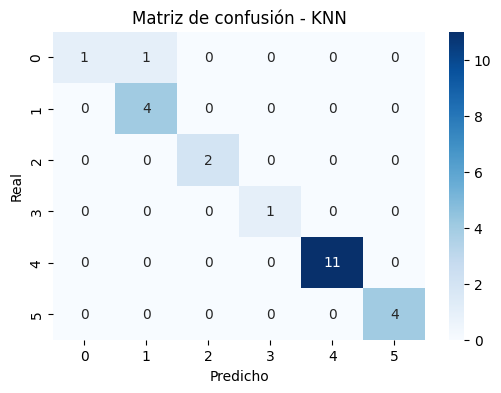


Entrenando modelo: Regresión Logística

Accuracy: 0.917

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         4
           2       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00        11
           6       1.00      0.75      0.86         4

    accuracy                           0.92        24
   macro avg       0.94      0.88      0.89        24
weighted avg       0.94      0.92      0.92        24



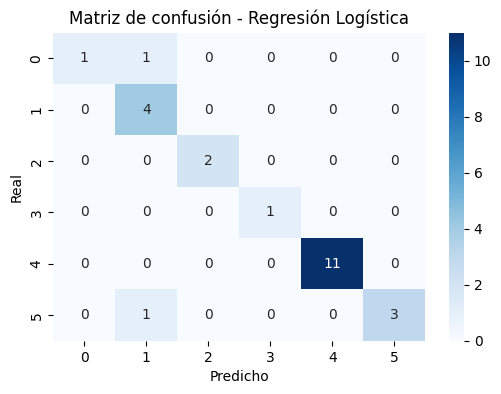


Entrenando modelo: Árbol de Decisión

Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.60      0.75      0.67         4
           2       0.67      1.00      0.80         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00        11
           6       1.00      0.50      0.67         4

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.86        24
weighted avg       0.91      0.88      0.87        24



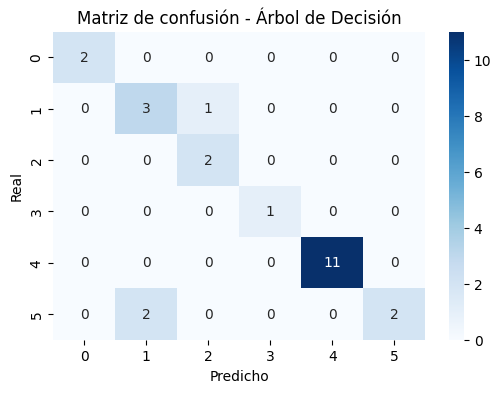

In [7]:
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\nEntrenando modelo: {nombre}")
    modelo.fit(X_train_scaled, y_train)

    # Predicciones sobre el conjunto de validación
    y_pred = modelo.predict(X_val_scaled)

    # Métricas
    acc = accuracy_score(y_val, y_pred)
    resultados[nombre] = acc

    print(f"\nAccuracy: {acc:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))

    # Matriz de confusión
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

### 2.3 - Comparación de los modelos

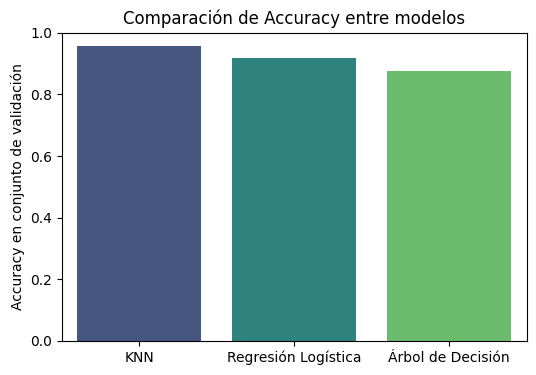


Resultados comparativos de Accuracy:
KNN                 : 0.958
Regresión Logística : 0.917
Árbol de Decisión   : 0.875


In [8]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x=list(resultados.keys()),
    y=list(resultados.values()),
    hue=list(resultados.keys()),     
    palette='viridis',
    legend=False
)
plt.title("Comparación de Accuracy entre modelos")
plt.ylabel("Accuracy en conjunto de validación")
plt.ylim(0, 1)
plt.show()


print("\nResultados comparativos de Accuracy:")
for modelo, acc in resultados.items():
    print(f"{modelo:20s}: {acc:.3f}")

# PARTE C